# DL4NLP Exercise 4
In this exercise, you will apply your knowledge of RAG, CoT and MoE.

# Setup
Run the following cell first

In [1]:
!pip install langchain langchain-chroma langchain-huggingface langchain-community langchain-groq pypdf semanticscholar

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFacePipeline
from langchain.tools import tool
from langchain_classic.agents import AgentExecutor, create_react_agent
from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from semanticscholar import SemanticScholar
import os

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9

/tmp/ipykernel_444/1054842343.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


# Task 1: Langchain & RAG (5 Points)

In this task, you will build a simple application with Langchain - a tool for extending LLMs with additional knowledge and capabilities. The goal of the task is to give a model access to additional information.

Let's say you want your LLM to help you understand SenDetEx - a paper about sentence-level AI generated text detection. This paper is not very well-known, so the chances are high the model does not know about it. To give the model this additional knowledge, you will create a vectorstore with the paper stored there, and compare the model's answers with and without access to the database.

## Task 1.1: Creating a vectorstore (3 Points)
First, you will create a vectorstore that contains the paper content.

### Task 1.1.1: Loading the paper (0.5 Points)

First, use PyPDFLoader to load the paper from ACL Anthology to colab as Langchain Documents (https://docs.langchain.com/oss/python/integrations/vectorstores/azure_cosmos_db_no_sql).

In [2]:
pdf_url = "https://aclanthology.org/2025.emnlp-main.268.pdf"
# TODO the paper PDF as a list of Documents
loader = PyPDFLoader(pdf_url)
pages = loader.load()

In [3]:
# Sanity check
print(pages[0].page_content)

Proceedings of the 2025 Conference on Empirical Methods in Natural Language Processing, pages 5287–5302
November 4-9, 2025 ©2025 Association for Computational Linguistics
SenDetEX: Sentence-Level AI-Generated Text Detection for Human-AI
Hybrid Content via Style and Context Fusion
Lei Jiang1, Desheng Wu1*, Xiaolong Zheng2
1University of Chinese Academy of Sciences, Beijing, China
2Institute of Automation, Chinese Academy of Sciences, Beijing, China
jianglei232@mails.ucas.ac.cn, dwu@ucas.ac.cn, xiaolong.zheng@ia.ac.cn
Abstract
Text generated by Large Language Models
(LLMs) now rivals human writing, raising con-
cerns about its misuse. However, mainstream
AI-generated text detection (AGTD) methods
primarily target document-level long texts and
struggle to generalize effectively to sentence-
level short texts. And current sentence-level
AGTD (S-AGTD) research faces two signifi-
cant limitations: (1) lack of a comprehensive
evaluation on complex human-AI hybrid con-
tent, where human-writte

### Task 1.1.2: Chunking the paper (1 Point)

By default, PyPDFLoader splits a PDF into documents by pages. These could be too big to retrieve at once. We want to chunk the documents by using RecursiveCharacterTextSplitter (https://reference.langchain.com/python/langchain-text-splitters/character/RecursiveCharacterTextSplitter). Use a chunk size of 512 characters and overlap of 32 characters.

In [4]:
# TODO initialize size and overlap values
chunk_size = 512
chunk_overlap = 32

# TODO instantiate the splitter and use it to split the pages
splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
chunks = splitter.split_documents(pages)


In [5]:
# Sanity check
print(len(chunks))

133


### Task 1.1.3: Creating a vectorstore (1 Point)

Now you can initialize your Vectorstore. There are many different vectorstore engines; we use Chroma here (https://docs.langchain.com/oss/python/integrations/vectorstores/chroma). Initialize a database from your chunks using the emedding model "sentence-transformers/all-mpnet-base-v2" and load the chunks into collection called "papers". Store the database in a persistent directory named chroma_db.

In [6]:
embeddings = HuggingFaceEmbeddings(
    # TODO load the embedding model
     model_name="sentence-transformers/all-mpnet-base-v2"
)
persist_dir = "./chroma_db"
# TODO create a Chroma vectorstore
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name="papers",
    persist_directory=persist_dir
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
# Sanity check
print(vectorstore._collection.count())

133


### Task 1.1.4: Test the vectorstore (0.5 Points)

Perform similarity search to test the database. Search for the term "SenDetEx text detection" and retrieve 5 most relevant documents.

In [8]:
search_term = "SenDetEx text detection"
# TODO test similarity search on your database
results = vectorstore.similarity_search(
    search_term,
    k=5
)

In [9]:
# Sanity check
print(results[0])

page_content='First, SenDetEX’s effectiveness relies on the pre-
ceding context of the sentence to be detected. Its
advantage will diminish in sparse or noisy context
scenarios, such as isolated sentences or fragmented
documents. Second, the proxy model plays a cru-
cial role in SenDetEX, and there is room for further
exploration regarding the present fine-tuning strat-
egy. Additionally, the prompts used in synthesizing
our dataset can be further optimized. We plan to
address these issues in future work.' metadata={'author': '', 'source': 'https://aclanthology.org/2025.emnlp-main.268.pdf', 'keywords': '', 'page_label': '5295', 'title': '', 'moddate': '2025-10-29T10:44:34-04:00', 'page': 8, 'total_pages': 16, 'trapped': '/False', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) kpathsea version 6.4.1', 'subject': '', 'creationdate': '2025-10-29T10:44:34-04:00', 'creator': 'LaTeX with hyperref', 'producer': 'pdfTeX-1.40.27'}


## Task 1.2: Extending LLM knowledge (2 Points)

Now, you will inference a model and compare its answers with and without access to the database.

For the inference, we use GroqCloud (https://console.groq.com) - a platform for free model inference (no credit card required). Setup steps:
- Create an account and log in
- Click on "API Keys" in the top-right corner, and create a new API key.
- For Colab users: Click on the Secrets symbol in the left sidebar and add your API key under name GROQ_API_KEY
- For local users: Create a .env file and load your key with GROQ_API_KEY=...

In [10]:
# Set the environment variable GROQ_API_KEY either locally or via Colab Secrets
try:
    from google.colab import userdata
    os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
except ImportError:
    from dotenv import load_dotenv
    load_dotenv()

### Task 1.2.1: Inference without RAG (0.5 Points)

Load "llama-3.3-70b-versatile" as langchain ChatGroq model and do simple inference without database access.

In [11]:
# TODO load the model
llm = ChatGroq(model="llama-3.3-70b-versatile")

question = "What is SenDetEx?"
answer = llm.invoke(question) # TODO inference the model

In [12]:
# Sanity check
# expected: the model does not know about SenDetEx
print(answer.content)

I'm not familiar with the term SenDetEx. Could you please provide more context or information about what SenDetEx refers to? This will help me better understand and provide a more accurate response.


### Task 1.2.2: Creating a RAG retrieval chain (1 Point)

Langchain operates with retrieval chains. Chains can contain:
- Retriever: your vectorstore in retriever format
- Prompt template: Prompt with inputs variables marked with \{variable_name\}. Langchain will fill these out depending on the type of task and user prompt and pass the final prompt to the LLM.
- LLM: your initialized model

Chains can have different purposes (e.g. a retrieval chain or a generation chain) and are often combined with each other (https://reference.langchain.com/python/langchain-classic/chains/retrieval/create_retrieval_chain).

In [13]:
prompt = PromptTemplate.from_template(
    """Use the context below to answer the question.
If the context does not contain enough information, just say so.

Context:
{context}

Question:
{input}

Answer:
    """
)

# Create a QA chain
qa_chain = create_stuff_documents_chain(llm, prompt)
# TODO create a retriever from the vectorstore with k = 10
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})
# Create retrieval chain
chain = create_retrieval_chain(retriever, qa_chain)

In [14]:
# Sanity check
# expected: first step is retrieval, second - generation
print(chain.steps)

[RunnableAssign(mapper={
  context: RunnableBinding(bound=RunnableLambda(lambda x: x['input'])
           | VectorStoreRetriever(tags=['Chroma', 'HuggingFaceEmbeddings'], vectorstore=<langchain_chroma.vectorstores.Chroma object at 0x7edeef38daf0>, search_kwargs={'k': 10}), kwargs={}, config={'run_name': 'retrieve_documents'}, config_factories=[])
}), RunnableAssign(mapper={
  answer: RunnableBinding(bound=RunnableBinding(bound=RunnableAssign(mapper={
            context: RunnableLambda(format_docs)
          }), kwargs={}, config={'run_name': 'format_inputs'}, config_factories=[])
          | PromptTemplate(input_variables=['context', 'input'], input_types={}, partial_variables={}, template='Use the context below to answer the question.\nIf the context does not contain enough information, just say so.\n\nContext:\n{context}\n\nQuestion:\n{input}\n\nAnswer:\n    ')
          | ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, pro

### Task 1.2.3: Inference with RAG (0.5 Points)

Inference the model again, now via chain invocation.

In [15]:
question = "What is SenDetEx?"
# TODO generate the answer via chain
answer = chain.invoke({"input": question})

In [16]:
# Sanity check
# expected: now the model knows about SenDetEx
print(answer["answer"])

SenDetEX is a detection model, specifically designed for sentence authorship attribution, which aims to identify the author of a given sentence. It is trained using the AdamW optimizer and utilizes a combination of feature encoding, style extraction, and information fusion modules to classify sentence authorship. The model has been evaluated under various scenarios, including in-domain, cross-generator, cross-domain, and adversarial attack settings, and has demonstrated strong performance and robustness.


# Task 2: Extending LLM capabilities (3.5 Points)

In this task, you will continue working with Langchain. This time, you will create an AI agent system that queries the semantic scholar API and retrieves most relevant papers in the CS field.


## Task 2.1: Create a tool (2 Points)

Langchain agents operate with tools. A tool is a Python method with a tool decorator and a docstring (https://docs.langchain.com/oss/python/langchain/tools).
First, you have to implement a tool for paper search using the python Semantic Scholar API (https://semanticscholar.readthedocs.io/en/latest/mainclasses/semanticscholar.html). Your function should:
- Search for relevant papers in the field of Computer Science, sorted by descending number of citations.
- Limit the number of output paper to n_results
- For each paper, if an abstract exists, truncate it to the first 200 tokens plus "...". Otherwise, abstract is an empty string
- Return a list of dicts with keys: title, url, year, citationCount, fieldsOfStudy, abstract.

The function must have a tool decorator with name "paper_search" and a docstring!

In [17]:
@tool("paper_search")
def search_semantic_scholar(query: str, n_results: int = 5):
    """
    Search Semantic Scholar for Computer Science papers sorted by citation count.
    Return the top n_results papers with title, url, year, citationCount,
    fieldsOfStudy, and a truncated abstract.
    """

    scholar = SemanticScholar()

    results = scholar.search_paper(
        query=query,
        fields_of_study=["Computer Science"],
        bulk=True,
        sort="citationCount:desc",
        limit=n_results
    )

    papers = []

    for paper in results.items:

        # Keep only Computer Science papers
        if not paper.fieldsOfStudy or "Computer Science" not in paper.fieldsOfStudy:
            continue

        # Handle abstract
        abstract = paper.abstract or ""

        # Truncate abstract to first 200 words
        if abstract:
            words = abstract.split()
            if len(words) > 200:
                abstract = " ".join(words[:200]) + "..."

        papers.append({
            "title": paper.title,
            "url": paper.url,
            "year": paper.year,
            "citationCount": paper.citationCount,
            "fieldsOfStudy": paper.fieldsOfStudy,
            "abstract": abstract,
        })

        # Stop after collecting n_results papers
        if len(papers) == n_results:
            break

    return papers

Invoke the tool to test it.



In [18]:
# Sanity check
papers = search_semantic_scholar.invoke("image segmentation transformers")
print("N papers: ", len(papers))
for paper in papers:
  print("Paper name: ", paper["title"])
  print("Citation count: ", paper["citationCount"])
  print("Abstract length: ", len(paper["abstract"]))
  print("URL: ", paper["url"])
  print("Fields of study: ", paper["fieldsOfStudy"])
  print()

N papers:  5
Paper name:  Swin Transformer: Hierarchical Vision Transformer using Shifted Windows
Citation count:  33591
Abstract length:  1357
URL:  https://www.semanticscholar.org/paper/c8b25fab5608c3e033d34b4483ec47e68ba109b7
Fields of study:  ['Computer Science']

Paper name:  End-to-End Object Detection with Transformers
Citation count:  18920
Abstract length:  1245
URL:  https://www.semanticscholar.org/paper/962dc29fdc3fbdc5930a10aba114050b82fe5a3e
Fields of study:  ['Computer Science']

Paper name:  Emerging Properties in Self-Supervised Vision Transformers
Citation count:  9596
Abstract length:  994
URL:  https://www.semanticscholar.org/paper/ad4a0938c48e61b7827869e4ac3baffd0aefab35
Fields of study:  ['Computer Science']

Paper name:  A ConvNet for the 2020s
Citation count:  8684
Abstract length:  1415
URL:  https://www.semanticscholar.org/paper/177e957f5cd93229c9794ea652c646d2557b4a69
Fields of study:  ['Computer Science']

Paper name:  Zero-Shot Text-to-Image Generation
Citat

Initialize a template for the agent. The type of agent we will use is ReAct:

> Agents follow the ReAct (“Reasoning + Acting”) pattern, alternating between brief reasoning steps with targeted tool calls and feeding the resulting observations into subsequent decisions until they can deliver a final answer.



In [19]:
react_template = """Answer the following question as best you can using the tools below.

Available tools:
{tools}

Use EXACTLY this format:

Question: the input question
Thought: what to do next
Action: tool name (one of [{tool_names}])
Action Input: plain search query string ONLY — no JSON, no dicts, no quotes
Observation: tool result
... (repeat Thought/Action/Observation as needed)
Thought: I now know the final answer
Final Answer: your answer

Begin!

Question: {input}
Thought:{agent_scratchpad}"""

## Task 2.2: Create an agent executor (1 Point)

Create a ReAct agent (https://reference.langchain.com/python/langchain-classic/agents/react/agent/create_react_agent) and an AgentExecutor (https://reference.langchain.com/python/langchain-classic/agents/agent/AgentExecutor). The AgentExecutor determines the execution process, i.e. the maximum number of iterations, error handling etc.

In [20]:
# TODO create a prompt template from the template string
prompt = PromptTemplate.from_template(react_template)


# TODO instantiate the ReAct agent
agent = create_react_agent(llm=llm,tools=[search_semantic_scholar],prompt=prompt)


# TODO instantiate the agent executor
# Set number of maximum iterations to 5 and verbose to True to visualize the reasoning
agent_executor = AgentExecutor(agent=agent,tools=[search_semantic_scholar],max_iterations=5,verbose=True)

In [21]:
# Sanity check
print(agent_executor.max_iterations)
print(agent_executor.tools[0].name)

5
paper_search


## Task 2.3: Agent executor invocation (0.5 Points)

Invoke the agent executor. You should see the thinking and tool envokation process.

In [22]:
user_question = "I want to learn about newest papers in the field of image segmentation transformers. Provide me paper names, URLs and short infos"
# TODO invoke the executor with the question
answer = agent_executor.invoke({"input": user_question})



> Entering new AgentExecutor chain...
To find the newest papers in the field of image segmentation transformers, I should search for relevant papers on Semantic Scholar. I will use the paper_search tool to find the top papers related to "image segmentation transformers".

Action: paper_search
Action Input: image segmentation transformers
[{'title': 'Swin Transformer: Hierarchical Vision Transformer using Shifted Windows', 'url': 'https://www.semanticscholar.org/paper/c8b25fab5608c3e033d34b4483ec47e68ba109b7', 'year': 2021, 'citationCount': 33591, 'fieldsOfStudy': ['Computer Science'], 'abstract': 'This paper presents a new vision Transformer, called Swin Transformer, that capably serves as a general-purpose backbone for computer vision. Challenges in adapting Transformer from language to vision arise from differences between the two domains, such as large variations in the scale of visual entities and the high resolution of pixels in images compared to words in text. To address these

Finally, look at the resulting output.

In [23]:
# Sanity check
print(answer["output"])

Here are some of the newest papers in the field of image segmentation transformers: 

1. Swin Transformer: Hierarchical Vision Transformer using Shifted Windows - https://www.semanticscholar.org/paper/c8b25fab5608c3e033d34b4483ec47e68ba109b7
2. End-to-End Object Detection with Transformers - https://www.semanticscholar.org/paper/962dc29fdc3fbdc5930a10aba114050b82fe5a3e
3. TransUNet: Transformers Make Strong Encoders for Medical Image Segmentation - https://www.semanticscholar.org/paper/24b8a0b02bcb7934967757fc59d273a71ba67e30

These papers propose new transformer-based models for image segmentation tasks, including the Swin Transformer, DETR, and TransUNet. They demonstrate state-of-the-art performance on various benchmarks, including ImageNet, COCO, and ADE20K.


# Task 3: MoE Task(Routing and Load Balancing) (8.5 points)

In this section we will implement a small **sparse Mixture-of-Experts (MoE)** classifier on **AG News**.

The goal is to implement a dense classifier and Moe classifier and compare them:

1. A dense classifier
2. Expert routing
3. Sparse top-k expert dispatch
4. Switch-style load-balancing loss

Switch style load balancing loss helps prevent router collapse or expert overfitting. You can read more about it here: https://huggingface.co/blog/NormalUhr/moe-balance


We train two models:

| Model | Purpose |
|---|---|
| Dense baseline | Shared FFN, no experts |
| Sparse top-k MoE | Router selects top-k experts for each token |


## Install dependencies

In [24]:
!pip install datasets scikit-learn pandas matplotlib -q

## Imports and setup

We import PyTorch, Hugging Face datasets, metrics, and plotting utilities. The notebook automatically uses GPU if available.

In [25]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Load AG News

AG News has four labels:

```text
0 = World
1 = Sports
2 = Business
3 = Sci/Tech
```

In [26]:
dataset = load_dataset("fancyzhx/ag_news")

label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech",
    4: "Entertainment"
}
num_classes = 5

train_size = 8000
val_size = 2000
test_size = 3000

shuffled_train = dataset["train"].shuffle(seed=SEED)
train_data = shuffled_train.select(range(train_size))
val_data = shuffled_train.select(range(train_size, train_size + val_size))
test_data = dataset["test"].shuffle(seed=SEED).select(range(test_size))

print(train_data[0])
print("Train:", len(train_data), "Val:", len(val_data), "Test:", len(test_data))

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

{'text': 'Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.', 'label': 0}
Train: 8000 Val: 2000 Test: 3000


## Tokenization and vocabulary

We use a simple regex tokenizer and build a vocabulary from the training data.

In [27]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()


def build_vocab(dataset, max_vocab_size=20000, min_freq=2):
    counter = Counter()

    for example in dataset:
        counter.update(tokenize(example["text"]))

    vocab = {"<pad>": 0, "<unk>": 1}

    for word, freq in counter.most_common(max_vocab_size):
        if freq >= min_freq and word not in vocab:
            vocab[word] = len(vocab)

    return vocab


def encode_text(text, vocab, max_len=48):
    tokens = tokenize(text)

    input_ids = [vocab.get(tok, vocab["<unk>"]) for tok in tokens]
    input_ids = input_ids[:max_len]

    attention_mask = [1] * len(input_ids)

    while len(input_ids) < max_len:
        input_ids.append(vocab["<pad>"])
        attention_mask.append(0)

    return input_ids, attention_mask


vocab = build_vocab(train_data)
id_to_word = {idx: word for word, idx in vocab.items()}

## Dataset and dataloaders

Each example returns token IDs, an attention mask, and a label.

The attention mask is important for MoE because we must ignore padding tokens during pooling and expert-usage analysis.

In [28]:
class AGNewsDataset(Dataset):
    def __init__(self, data, vocab, max_len=48):
        self.data = data
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        input_ids, attention_mask = encode_text(
            item["text"],
            self.vocab,
            self.max_len
        )

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.float),
            "label": torch.tensor(item["label"], dtype=torch.long)
        }


max_len = 48
batch_size = 32

train_loader = DataLoader(
    AGNewsDataset(train_data, vocab, max_len),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    AGNewsDataset(val_data, vocab, max_len),
    batch_size=batch_size
)

test_loader = DataLoader(
    AGNewsDataset(test_data, vocab, max_len),
    batch_size=batch_size
)

batch = next(iter(train_loader))
print("input_ids:", batch["input_ids"].shape)
print("attention_mask:", batch["attention_mask"].shape)
print("label:", batch["label"].shape)

input_ids: torch.Size([32, 48])
attention_mask: torch.Size([32, 48])
label: torch.Size([32])


#### Mean pooling

Mean pooling averages token representations into one document representation.

In the dense baseline, we mean-pool immediately after embedding.

In the MoE model, we first apply MoE to each token and then mean-pool the MoE-transformed token outputs.

In [29]:
def mean_pool(embeddings, attention_mask):
    mask = attention_mask.unsqueeze(-1)
    summed = (embeddings * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1)
    return summed / counts

### Task 3.1: Dense classifier (1 point)

In this task you will implement a dense classifier. The dense classifier has one shared feed-forward network.

Before implementing the Mixture-of-Experts model, we first build a simple dense baseline classifier.

This model embeds each input token, passes every token embedding through the same feed-forward network, pools the token representations into one sentence representation, and finally predicts the class label.

In [30]:
import torch
import torch.nn as nn

class DenseClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 output_dim, num_classes, pad_idx=0):
        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_idx
        )

        # Feed-forward network
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.ReLU()
        )

        # Final classifier
        self.classifier = nn.Linear(output_dim, num_classes)

    def forward(self, input_ids, attention_mask):

        # 1. Token embeddings
        embeddings = self.embedding(input_ids)

        # 2. Mean pooling (ignoring padding)
        mask = attention_mask.unsqueeze(-1).float()
        masked_embeddings = embeddings * mask

        sum_embeddings = masked_embeddings.sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1)

        pooled = sum_embeddings / lengths

        # 3. Feed-forward network
        hidden = self.ffn(pooled)

        # 4. Classification
        logits = self.classifier(hidden)

        return logits

In [31]:
# sanity check

test_vocab_size = 100
test_num_classes = 4
test_embed_dim = 16
test_hidden_dim = 32
test_pad_idx = 0
test_output_dim = 8

dense_model = DenseClassifier(
    vocab_size=test_vocab_size,
    embed_dim=test_embed_dim,
    hidden_dim=test_hidden_dim,
    output_dim=test_output_dim,
    num_classes=test_num_classes,
    pad_idx=test_pad_idx
)

input_ids = torch.randint(1, test_vocab_size, (4, 7))
attention_mask = torch.ones_like(input_ids)

# add padding to check whether masked pooling works correctly
input_ids[0, -2:] = test_pad_idx
attention_mask[0, -2:] = 0

logits = dense_model(input_ids, attention_mask)
print("input_ids shape:", input_ids.shape)
print("attention_mask shape:", attention_mask.shape)
print("logits shape:", logits.shape)

input_ids shape: torch.Size([4, 7])
attention_mask shape: torch.Size([4, 7])
logits shape: torch.Size([4, 4])


### Task 3.2: Sparse top-k MoE (4 points)

This MoE layer does the following:

1. The router scores all experts.
2. Each token selects top-k experts.
3. For each expert, we gather only the tokens assigned to that expert.
4. The expert runs only on those selected tokens.
5. Weighted expert outputs are summed up.


#### Task 3.2.1: Expert network (1 point)

An expert is a small two-layer feed-forward network. In the MoE model, each token is routed to one or more experts. Since each expert has its own parameters, different experts can learn different transformations of the token representations.

In [32]:
import torch.nn as nn

class Expert(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        # Two-layer feed-forward network
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.ReLU()
        )

    def forward(self, x):
        # Pass input through the expert network
        return self.net(x)

In [33]:
# Sanity Check

expert = Expert(
    input_dim=16,
    hidden_dim=32,
    output_dim=8
)

x = torch.randn(5, 16)
y = expert(x)

print("Input shape: ", x.shape)
print("Output shape:", y.shape)

assert y.shape == (5, 8), "Expert output shape is wrong"
assert torch.isfinite(y).all(), "Expert output contains NaN or Inf"

print("Expert sanity check passed.")

Input shape:  torch.Size([5, 16])
Output shape: torch.Size([5, 8])
Expert sanity check passed.


#### Task 3.2.2: Router network (1 point)

The router decides which expert should process each token. It takes a token representation as input and produces one score for each expert.

These scores are converted into probabilities using softmax, so each token gets a probability distribution over the experts. Later, the MoE layer will use these probabilities to select the top-k experts for each token.

In [34]:
import torch
import torch.nn as nn

class Router(nn.Module):
    def __init__(self, input_dim, num_experts):
        super().__init__()

        # Linear router/gate
        self.gate = nn.Linear(input_dim, num_experts)

    def forward(self, x):
        # 1. Compute router logits
        logits = self.gate(x)

        # 2. Convert logits to probabilities
        router_probs = torch.softmax(logits, dim=-1)

        # 3. Return probabilities
        return router_probs

In [35]:
# sanity check

router = Router(
    input_dim=16,
    num_experts=4
)

x = torch.randn(6, 16)
router_probs = router(x)

print("Router probs shape:", router_probs.shape)
print("Row sums:", router_probs.sum(dim=-1))

Router probs shape: torch.Size([6, 4])
Row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)


#### Task 3.2.3: Top-k Mixture of Experts (2 points)

This layer routes each input item to only the top-k experts selected by the router. Each selected expert processes the item, and the weighted expert outputs are combined into one final output.

This is the main sparse computation step: instead of running all experts for every token, we only run the experts that were selected for that token.

In [36]:
import torch
import torch.nn as nn

class TopKMixtureOfExperts(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        num_experts,
        k=2
    ):
        super().__init__()

        assert k <= num_experts

        self.output_dim = output_dim
        self.num_experts = num_experts
        self.k = k

        # Create experts
        self.experts = nn.ModuleList([
            Expert(input_dim, hidden_dim, output_dim)
            for _ in range(num_experts)
        ])

        # Create router
        self.router = Router(input_dim, num_experts)

    def forward(self, x):

        # Router probabilities
        router_probs = self.router(x)

        # Top-k routing
        topk_probs, topk_indices = torch.topk(
            router_probs,
            self.k,
            dim=-1
        )

        # Normalize probabilities
        topk_probs = topk_probs / topk_probs.sum(
            dim=-1,
            keepdim=True
        )

        num_items = x.size(0)

        # Output tensor
        moe_output = torch.zeros(
            num_items,
            self.output_dim,
            device=x.device
        )

        # Sparse dispatch
        for expert_id, expert in enumerate(self.experts):

            mask = topk_indices == expert_id

            if not mask.any():
                continue

            item_positions, selected_positions = torch.where(mask)

            expert_input = x[item_positions]
            expert_output = expert(expert_input)

            weights = topk_probs[
                item_positions,
                selected_positions
            ].unsqueeze(-1)

            moe_output[item_positions] += weights * expert_output

        return moe_output, router_probs, topk_indices

In [37]:
# sanity check

moe_layer = TopKMixtureOfExperts(
    input_dim=16,
    hidden_dim=32,
    output_dim=8,
    num_experts=4,
    k=2
)

x = torch.randn(10, 16)

moe_output, router_probs, topk_indices = moe_layer(x)

print("input shape:       ", x.shape)
print("moE output shape:  ", moe_output.shape)
print("router probs shape:", router_probs.shape)
print("top-k shape:       ", topk_indices.shape)
print("top-k indices:")
print(topk_indices)

input shape:        torch.Size([10, 16])
moE output shape:   torch.Size([10, 8])
router probs shape: torch.Size([10, 4])
top-k shape:        torch.Size([10, 2])
top-k indices:
tensor([[0, 3],
        [0, 1],
        [3, 0],
        [0, 1],
        [2, 0],
        [1, 0],
        [0, 3],
        [0, 2],
        [2, 1],
        [2, 0]])


### Task 3.3: MoE classifier (1 point)



The MoE classifier replaces the single dense feed-forward network with multiple expert networks.

Instead of sending every token through the same dense layer, the model uses a router to decide which expert or experts should process each token. This allows different experts to specialize in different types of tokens or patterns.

In [38]:
import torch
import torch.nn as nn

class MoEClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        expert_hidden_dim,
        moe_output_dim,
        num_experts,
        k,
        num_classes,
        pad_idx=0
    ):
        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_idx
        )

        # Mixture-of-Experts layer
        self.moe = TopKMixtureOfExperts(
            input_dim=embed_dim,
            hidden_dim=expert_hidden_dim,
            output_dim=moe_output_dim,
            num_experts=num_experts,
            k=k
        )

        # Final classifier
        self.classifier = nn.Linear(
            moe_output_dim,
            num_classes
        )

    def forward(self, input_ids, attention_mask):


        embeddings = self.embedding(input_ids)

        batch_size, seq_len, embed_dim = embeddings.shape

        flat_embeddings = embeddings.view(
            batch_size * seq_len,
            embed_dim
        )

        # Apply MoE
        flat_moe_output, router_probs, topk_indices = self.moe(
            flat_embeddings
        )

        # Restore sentence structure
        token_moe_output = flat_moe_output.view(
            batch_size,
            seq_len,
            -1
        )

        #  Mean pooling
        mask = attention_mask.unsqueeze(-1).float()

        summed = (token_moe_output * mask).sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1)

        pooled = summed / lengths
        logits = self.classifier(pooled)
        return logits, router_probs, topk_indices

In [39]:
# sanity check

test_vocab_size = 100
test_num_classes = 4
test_embed_dim = 16
test_expert_hidden_dim = 32
test_moe_output_dim = 8
test_num_experts = 4
test_k = 2
test_pad_idx = 0

model = MoEClassifier(
    vocab_size=test_vocab_size,
    embed_dim=test_embed_dim,
    expert_hidden_dim=test_expert_hidden_dim,
    moe_output_dim=test_moe_output_dim,
    num_experts=test_num_experts,
    k=test_k,
    num_classes=test_num_classes,
    pad_idx=test_pad_idx
)

input_ids = torch.randint(1, test_vocab_size, (4, 7))
attention_mask = torch.ones_like(input_ids)

# add some padding to test masked pooling
input_ids[0, -2:] = test_pad_idx
attention_mask[0, -2:] = 0

logits, router_probs, topk_indices = model(input_ids, attention_mask)
print("input_ids shape:   ", input_ids.shape)
print("logits shape:      ", logits.shape)
print("router_probs shape:", router_probs.shape)
print("topk_indices shape:", topk_indices.shape)

input_ids shape:    torch.Size([4, 7])
logits shape:       torch.Size([4, 4])
router_probs shape: torch.Size([28, 4])
topk_indices shape: torch.Size([28, 2])


### Task 3.4: Switch-style load-balancing loss (1.5 points)

We use a Switch-style load-balancing loss:

```text
L_aux = N × Σ_i f_i P_i
```

where:

- `N` is the number of experts
- `f_i` is the fraction of tokens dispatched to expert `i`
- `P_i` is the average router probability assigned to expert `i`

For top-k routing, the unnormalized balanced value is approximately `k`, so we divide by `k` to keep the balanced value close to `1.0`.


In [40]:
def load_balancing_loss(
    router_probs,
    topk_indices,
    attention_mask,
    normalize_by_k=True
):
    """
    Switch-style auxiliary load-balancing loss.

    router_probs:
        [batch_size * seq_len, num_experts]
    topk_indices:
        [batch_size * seq_len, k]
    attention_mask:
        [batch_size, seq_len]

    Goal:
        Encourage balanced expert usage over real tokens only.
    """

    # TODO:
   # Get batch size and sequence length
    batch_size, seq_len = attention_mask.shape

    # Number of experts and top-k
    num_experts = router_probs.size(-1)
    k = topk_indices.size(-1)

    # Reshape
    router_probs = router_probs.view(
        batch_size,
        seq_len,
        num_experts
    )

    topk_indices = topk_indices.view(
        batch_size,
        seq_len,
        k
    )

    # Keep only real tokens
    real_token_mask = attention_mask.bool()

    real_router_probs = router_probs[real_token_mask]
    real_topk_indices = topk_indices[real_token_mask]

    # Expert selection matrix
    expert_selected = torch.zeros_like(real_router_probs)

    expert_selected.scatter_(
        dim=1,
        index=real_topk_indices,
        value=1.0
    )

    # Fraction of tokens routed to each expert
    f = expert_selected.float().mean(dim=0).detach()

    # Average router probability
    P = real_router_probs.mean(dim=0)

    # Switch-style loss
    loss = num_experts * torch.sum(f * P)

    # Normalize for top-k routing
    if normalize_by_k:
        loss = loss / k

    return loss

In [41]:
# sanity check for load_balancing_loss with k=1
# balanced loss should be close to 1.0

router_probs = torch.tensor([
    [0.8, 0.2],
    [0.1, 0.9],
    [0.7, 0.3],
    [0.4, 0.6],
], dtype=torch.float32)

topk_indices = torch.tensor([
    [0],
    [1],
    [0],
    [1],
], dtype=torch.long)

attention_mask = torch.tensor([
    [1, 1, 1, 1]
], dtype=torch.long)

loss = load_balancing_loss(
    router_probs=router_probs,
    topk_indices=topk_indices,
    attention_mask=attention_mask,
    normalize_by_k=True
)

print("Load-balancing loss:", loss.item())

Load-balancing loss: 1.0


In [42]:
# sanity Check with k=2
# balanced loss should be close to 1.0 when normalize_by_k=True

router_probs = torch.tensor([
    [0.5, 0.5],
    [0.5, 0.5],
], dtype=torch.float32)

topk_indices = torch.tensor([
    [0, 1],
    [0, 1],
], dtype=torch.long)

attention_mask = torch.tensor([
    [1, 1]
], dtype=torch.long)

loss = load_balancing_loss(
    router_probs=router_probs,
    topk_indices=topk_indices,
    attention_mask=attention_mask,
    normalize_by_k=True
)

print("Load-balancing loss:", loss.item())

Load-balancing loss: 1.0


### Task 3.5: Evaluation and training (0.5 points)

The dense model uses ordinary cross-entropy.

The MoE model uses:

```text
cross-entropy loss + aux_weight × load-balancing loss
```

### Training with auxiliary loss

Most training/evaluation code is provided. Complete the MoE training loss.



Evaluate functions for dense and moe models:

In [43]:
def evaluate_dense(model, data_loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids, attention_mask)
            preds = torch.argmax(logits, dim=-1)

            all_preds.append(preds)
            all_labels.append(labels)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    acc = (all_preds == all_labels).float().mean()

    return acc.item()


def evaluate_moe(model, data_loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits, _, _ = model(input_ids, attention_mask)
            preds = torch.argmax(logits, dim=-1)

            all_preds.append(preds)
            all_labels.append(labels)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    acc = (all_preds == all_labels).float().mean()

    return acc.item()

Training function for dense model:

In [44]:
def train_dense_model(model, train_loader, val_loader, device, epochs=3, lr=1e-3):
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        val_acc = evaluate_dense(model, val_loader)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"loss={total_loss/len(train_loader):.4f} | "
            f"val_acc={val_acc:.4f} | "
        )

    return model

#### Task 3.5.1: Training function for moe model.  (0.5 points)
Compute load balancing loss using the function implemented above and add it to ce-loss to compute final loss.

In [45]:
def train_moe_model(model, train_loader, val_loader, device, epochs=3, lr=1e-3, aux_weight=0.1):
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_cls_loss = 0.0
        total_balance_loss = 0.0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()

            logits, router_probs, topk_indices = model(
                input_ids,
                attention_mask
            )

            cls_loss = criterion(logits, labels)

            # TODO:
            # Compute load-balancing loss using router_probs, topk_indices,
            # attention_mask, and normalize_by_k=True.
            balance_loss = load_balancing_loss(
    router_probs,
    topk_indices,
    attention_mask,
    normalize_by_k=True
)

            # TODO:
            # Combine ce loss and auxiliary loss.
            loss = cls_loss + aux_weight * balance_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_cls_loss += cls_loss.item()
            total_balance_loss += balance_loss.item()

        val_acc = evaluate_moe(model, val_loader)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"loss={total_loss/len(train_loader):.4f} | "
            f"cls_loss={total_cls_loss/len(train_loader):.4f} | "
            f"balance_loss={total_balance_loss/len(train_loader):.4f} | "
            f"val_acc={val_acc:.4f} | "
        )

    return model

#### Hyperparameters

In [46]:
vocab_size = len(vocab)

embed_dim = 64
hidden_dim = 128
output_dim = 64

moe_expert_hidden_dim = 128
moe_output_dim = 64

num_experts = 4
k = 2

epochs = 10
lr = 1e-3

aux_weight = 0.05

### Train dense classifier

In this cell, we train the dense baseline classifier.

For each batch, the model predicts class logits from the input text. We then compute the cross-entropy loss between the predicted logits and the gold labels, backpropagate the loss, and update the model parameters with the optimizer.

This baseline does not use routing or experts. Every token is processed by the same feed-forward network. Because of this, it is a useful comparison point for the MoE model.

In [47]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [48]:
dense_model = DenseClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    output_dim = output_dim,
    num_classes=num_classes,
    pad_idx=vocab["<pad>"]
)

print("Dense parameters:", count_parameters(dense_model))

dense_model = train_dense_model(
    dense_model,
    train_loader,
    val_loader,
    device=device,
    epochs=epochs,
    lr=lr
)

dense_acc = evaluate_dense(dense_model, test_loader)

print("Dense Test Accuracy:", dense_acc)

Dense parameters: 882565
Epoch 1/10 | loss=1.1589 | val_acc=0.6760 | 
Epoch 2/10 | loss=0.6342 | val_acc=0.7685 | 
Epoch 3/10 | loss=0.4453 | val_acc=0.7985 | 
Epoch 4/10 | loss=0.3352 | val_acc=0.8070 | 
Epoch 5/10 | loss=0.2542 | val_acc=0.8170 | 
Epoch 6/10 | loss=0.1918 | val_acc=0.8205 | 
Epoch 7/10 | loss=0.1381 | val_acc=0.8215 | 
Epoch 8/10 | loss=0.0985 | val_acc=0.8235 | 
Epoch 9/10 | loss=0.0672 | val_acc=0.8230 | 
Epoch 10/10 | loss=0.0444 | val_acc=0.8160 | 
Dense Test Accuracy: 0.8316666483879089


### Sparse MoE
In this cell, we train the Mixture-of-Experts classifier.

The MoE model has two training objectives:

1. **Classification loss**: teaches the model to predict the correct class label.
2. **Load-balancing loss**: encourages the router to use all experts instead of always choosing the same one.

The total loss is:

```python
total_loss = classification_loss + aux_weight * load_balancing_loss

In [49]:
moe_model = MoEClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    expert_hidden_dim=moe_expert_hidden_dim,
    moe_output_dim=moe_output_dim,
    num_experts=num_experts,
    k=k,
    num_classes=num_classes,
    pad_idx=vocab["<pad>"]
)

print("MoE parameters:", count_parameters(moe_model))

moe_model = train_moe_model(
    moe_model,
    train_loader,
    val_loader,
    device=device,
    epochs=epochs,
    lr=lr,
    aux_weight=aux_weight
)

moe_model_acc = evaluate_moe(
    moe_model,
    test_loader
)

print("MoE Test Accuracy:", moe_model_acc)

MoE parameters: 932553
Epoch 1/10 | loss=1.2332 | cls_loss=1.1831 | balance_loss=1.0023 | val_acc=0.7185 | 
Epoch 2/10 | loss=0.6313 | cls_loss=0.5812 | balance_loss=1.0008 | val_acc=0.8135 | 
Epoch 3/10 | loss=0.4440 | cls_loss=0.3939 | balance_loss=1.0021 | val_acc=0.8270 | 
Epoch 4/10 | loss=0.3471 | cls_loss=0.2969 | balance_loss=1.0037 | val_acc=0.8400 | 
Epoch 5/10 | loss=0.2746 | cls_loss=0.2244 | balance_loss=1.0032 | val_acc=0.8455 | 
Epoch 6/10 | loss=0.2204 | cls_loss=0.1703 | balance_loss=1.0029 | val_acc=0.8500 | 
Epoch 7/10 | loss=0.1715 | cls_loss=0.1214 | balance_loss=1.0012 | val_acc=0.8435 | 
Epoch 8/10 | loss=0.1358 | cls_loss=0.0858 | balance_loss=0.9986 | val_acc=0.8460 | 
Epoch 9/10 | loss=0.1065 | cls_loss=0.0564 | balance_loss=1.0003 | val_acc=0.8300 | 
Epoch 10/10 | loss=0.0863 | cls_loss=0.0364 | balance_loss=0.9984 | val_acc=0.8390 | 
MoE Test Accuracy: 0.8503333330154419


### Overall expert-usage analysis
After training the MoE model, we want to inspect how often each expert is selected.

This visualization counts how many tokens were routed to each expert across the dataset. The result helps us check whether the router is using all experts or whether it collapsed to only one or two experts.

It helps us answer the following questions:
- Are all experts being used?
- Is one expert selected much more often than the others?

If the plot shows that almost all tokens go to one expert, then the router has likely collapsed. If the usage is more balanced, then the model is making use of multiple experts.

In [50]:
def collect_token_expert_selection_counts(model, data_loader, num_experts):
    model.eval()

    counts = torch.zeros(num_experts, device=device)

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            logits, router_probs, topk_indices = model(
                input_ids,
                attention_mask
            )

            batch_size, seq_len = attention_mask.shape

            topk_indices = topk_indices.reshape(
                batch_size,
                seq_len,
                -1
            )

            real_token_mask = attention_mask.bool()
            selected_real_tokens = topk_indices[real_token_mask]
            selected = selected_real_tokens.reshape(-1)

            batch_counts = torch.bincount(
                selected,
                minlength=num_experts
            ).float()

            counts += batch_counts

    usage = counts / counts.sum().clamp(min=1)

    return usage

Here, we show a table to show the selection frequency for each expert. Selection frequency here means how many times an expert was chosen with test dataset

In [51]:
usage_with_aux = collect_token_expert_selection_counts(
    moe_model,
    test_loader,
    num_experts
)

usage_with_aux_values = usage_with_aux.detach().tolist()

expert_usage_df = pd.DataFrame({
    "Expert": [f"Expert {i}" for i in range(num_experts)],
    "Selection frequency": usage_with_aux_values
})

expert_usage_df


,Expert,Selection frequency
0,Expert 0,0.280869
1,Expert 1,0.241893
2,Expert 2,0.259362
3,Expert 3,0.217876


Same as above. Here, we plot a bar graph to show the selection frequency for each expert. Selection frequence here means how many times an expert was chosen with test dataset

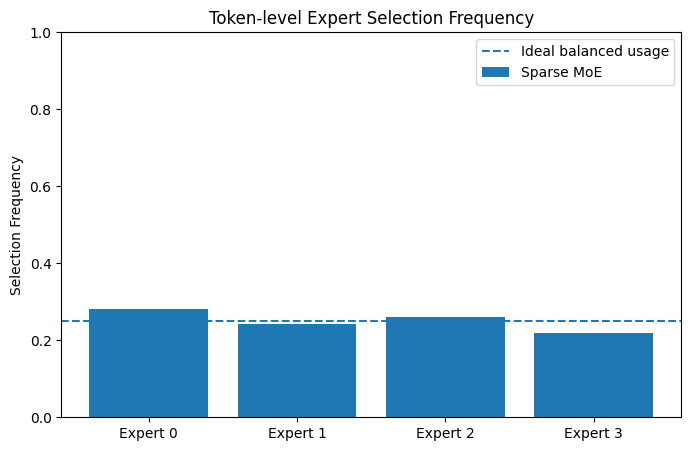

In [52]:
x = np.arange(num_experts)

plt.figure(figsize=(8, 5))
plt.bar(x, usage_with_aux_values, label="Sparse MoE")
plt.axhline(
    1.0 / num_experts,
    linestyle="--",
    label="Ideal balanced usage"
)

plt.xticks(x, [f"Expert {i}" for i in range(num_experts)])
plt.ylabel("Selection Frequency")
plt.title("Token-level Expert Selection Frequency")
plt.ylim(0, 1)
plt.legend()
plt.show()


### Token-level expert usage
Overall expert usage tells us whether the experts are used, but it does not tell us what they are used for.

In this analysis, we look at individual tokens and count which experts are selected for them. For example, we may find that punctuation, stopwords, sentiment words, or topic-specific words are routed to different experts.

The goal is not to prove perfect linguistic specialization. Instead, the goal is to inspect whether the router has learned any meaningful routing patterns.

In [66]:
def collect_token_expert_usage(
    model,
    data_loader,
    id_to_word,
    num_experts,
    min_count=20,
    max_words=60
):
    model.eval()

    word_expert_counts = defaultdict(lambda: np.zeros(num_experts))
    word_counts = Counter()

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            logits, router_probs, topk_indices = model(
                input_ids,
                attention_mask
            )

            batch_size, seq_len = input_ids.shape

            topk_indices = topk_indices.reshape(
                batch_size,
                seq_len,
                -1
            )

            input_ids_list = input_ids.detach().tolist()
            mask_list = attention_mask.detach().tolist()
            selected_list = topk_indices.detach().tolist()

            for b in range(batch_size):
                for t in range(seq_len):
                    if mask_list[b][t] == 0:
                        continue

                    token_id = int(input_ids_list[b][t])
                    word = id_to_word.get(token_id, "<unk>")

                    if word in ["<pad>", "<unk>"]:
                        continue

                    word_counts[word] += 1

                    for expert_id in selected_list[b][t]:
                        word_expert_counts[word][expert_id] += 1

    rows = {}

    for word, counts in word_expert_counts.items():
        if word_counts[word] >= min_count:
            rows[word] = counts / counts.sum()

    sorted_words = [
        word for word, _ in word_counts.most_common()
        if word in rows
    ][:max_words]

    return pd.DataFrame(
        {word: rows[word] for word in sorted_words}
    ).T


In [54]:
word_usage_df = collect_token_expert_usage(
    moe_model,
    test_loader,
    id_to_word,
    num_experts=num_experts,
    min_count=20,
    max_words=60
)

word_usage_df.head()

,0,1,2,3
the,0.5,0.5,0.0,0.0
to,0.5,0.5,0.0,0.0
a,0.5,0.0,0.5,0.0
of,0.0,0.0,0.5,0.5
in,0.5,0.0,0.5,0.0


# Task 4: Chain-of-Thought Prompting on GSM8K  (3 points)


In this task You will compare two prompting strategies on a small subset of **GSM8K**, a grade-school math word-problem dataset:

1. **Standard prompting**: ask the model for only the final answer.
2. **Zero-shot Chain-of-thought prompting**: ask the model to reason step by step to provide the answer.



### Install dependencies

We use:

- `datasets` to load GSM8K
- `groq` as the example LLM API client



In [55]:
!pip install -q -U transformers accelerate
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 107.9 MB/s eta 0:00:00


### Imports and setup


In [56]:
import os
import re
from datasets import load_dataset

SEED = 42

### Load GSM8K subset

GSM8K contains math word problems.

Each example has:

- `question`: the problem statement
- `answer`: a full worked solution, ending with the final answer after `####`

Example:

```text
... reasoning ... #### 42
```

In [57]:
gsm = load_dataset("openai/gsm8k", "main")

num_examples = 10

gsm_subset = (
    gsm["test"]
    .shuffle(seed=SEED)
    .select(range(num_examples))
)

print("Question example:")
print(gsm_subset[0]["question"])
print()
print("Gold answer example:")
print(gsm_subset[0]["answer"])
print()

README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Question example:
Darrell and Allen's ages are in the ratio of 7:11. If their total age now is 162, calculate Allen's age 10 years from now.

Gold answer example:
The total ratio representing their ages is 7+11= <<7+11=18>>18
Since the fraction of the ratio that represents Allen's age is 11/18, Allen's current age is 11/18*162 = <<11/18*162=99>>99
If Allen is currently 99 years old, in 10 years he will be 99+10 = <<99+10=109>>109 years old
#### 109



### Extract GSM8K gold final answers

This setup cell extracts the final answer from GSM8K's `####` format.


In [58]:
def extract_gsm8k_gold_answer(answer_text):
    if "####" not in answer_text:
        return answer_text.strip()

    return answer_text.split("####")[-1].strip()


test_samples = []

for ex in gsm_subset:
    test_samples.append({
        "question": ex["question"],
        "gold_answer": extract_gsm8k_gold_answer(ex["answer"]),
        "full_gold_solution": ex["answer"]
    })

### Load Qwen model from hugging face

Set seed and load the Qwen2.5-1.5B-Instruct model and its tokenizer from Hugging Face.

In [59]:
import os
import random
import numpy as np
import torch
from transformers import set_seed

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

set_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [60]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
).to(device)

model.eval()

print("Running on:", device)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Running on: cuda



This cell defines `call_model`, which takes a prompt string and returns the model's response.

In [61]:
def call_model(prompt, max_tokens=256):
    messages = [
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(device)

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    new_tokens = generated_ids[:, inputs["input_ids"].shape[1]:]

    output = tokenizer.batch_decode(
        new_tokens,
        skip_special_tokens=True
    )[0]

    return output.strip()

Helper function to extract answers from model outputs.

In [62]:
def extract_final_answer(model_output):
    matches = re.findall(
        r"(?:Answer|The answer is)\s*:?\s*"
        r"([-+]?\d+(?:,\d{3})*(?:\.\d+)?)",
        model_output,
        flags=re.IGNORECASE
    )

    if matches:
        return matches[-1].strip()

    # Last numeric value as a final fallback
    numbers = re.findall(
        r"[-+]?\d+(?:,\d{3})*(?:\.\d+)?",
        model_output
    )

    if numbers:
        return numbers[-1]

    return None

### Task 4.1: Generate standard and CoT prompts (1 point)

Implement a function that creates the correct prompt depending on the strategy.

### Standard prompting

Just use the normal prompt.

### Zero-shot Chain-of-thought prompting

The model should reason step by step.


In [63]:
def generate_prompt(sample, strategy):
    question = sample["question"]

    if strategy == "standard":
        # Ask for only the final numeric answer
        prompt = f"""
Solve the following math word problem.

Question:
{question}

Return only the final numeric answer.
"""

    elif strategy == "cot":
        # Ask the model to reason step by step
        prompt = f"""
Solve the following math word problem.

Question:
{question}

Think step by step before giving your answer.

End your response with:
Final Answer: <answer>
"""

    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    return prompt.strip()

In [64]:
sample = {
    "question": "If John has 3 apples and buys 4 more, how many apples does he have?"
}

standard_prompt = generate_prompt(sample, "standard")
cot_prompt = generate_prompt(sample, "cot")

print("STANDARD PROMPT:")
print(standard_prompt)

print("\n" + "=" * 80 + "\n")

print("COT PROMPT:")
print(cot_prompt)

STANDARD PROMPT:
Solve the following math word problem.

Question:
If John has 3 apples and buys 4 more, how many apples does he have?

Return only the final numeric answer.


COT PROMPT:
Solve the following math word problem.

Question:
If John has 3 apples and buys 4 more, how many apples does he have?

Think step by step before giving your answer.

End your response with:
Final Answer: <answer>


example output

STANDARD PROMPT:
If John has 3 apples and buys 4 more, how many apples does he have?

================================================================================

COT PROMPT:
Question: If John has 3 apples and buys 4 more, how many apples does he have?. Let's think step by step.

### Task 4.2: Evaluate standard prompting vs zero-shot CoT prompting (2 points)

For each GSM8K sample:

1. Generate a standard prompt.
2. Generate a zero-shot CoT prompt.
3. Call the model for both.
4. Extract and normalize the predicted answers.
5. Compare against the gold answer.


In [65]:
strategies = ["standard", "cot"]
results = {strategy: [] for strategy in strategies}
rows = []

for i, sample in enumerate(test_samples):
    gold = sample["gold_answer"]

    row = {
        "index": i,
        "question": sample["question"],
        "gold": gold
    }

    for strategy in strategies:

        # 1. Generate prompt
        prompt = generate_prompt(sample, strategy)

        # 2. Generate model output
        max_tokens = 32 if strategy == "standard" else 256
        output = call_model(prompt, max_tokens=max_tokens)

        # 3. Extract answer
        pred = extract_final_answer(output)

        # 4. Compare with gold answer
        correct = (pred == gold)

        results[strategy].append(correct)

        row[f"{strategy}_output"] = output
        row[f"{strategy}_prediction"] = pred
        row[f"{strategy}_correct"] = correct

    rows.append(row)

    print(
        f"Example {i + 1}/{len(test_samples)}, "
        f"Standard: {row['standard_correct']}, "
        f"CoT: {row['cot_correct']}, "
        f"Standard pred: {row['standard_prediction']}, "
        f"CoT pred: {row['cot_prediction']}"
    )

Example 1/10, Standard: False, CoT: False, Standard pred: 48, CoT pred: 18
Example 2/10, Standard: False, CoT: False, Standard pred: 120, CoT pred: 1
Example 3/10, Standard: False, CoT: True, Standard pred: 10, CoT pred: 13
Example 4/10, Standard: False, CoT: True, Standard pred: 8, CoT pred: 5
Example 5/10, Standard: False, CoT: False, Standard pred: 18, CoT pred: 18
Example 6/10, Standard: False, CoT: False, Standard pred: 23, CoT pred: 720
Example 7/10, Standard: False, CoT: True, Standard pred: 39, CoT pred: 43
Example 8/10, Standard: False, CoT: False, Standard pred: 40, CoT pred: 40
Example 9/10, Standard: False, CoT: False, Standard pred: 600, CoT pred: 40
Example 10/10, Standard: False, CoT: False, Standard pred: 18, CoT pred: 5
